# Phase 7: Regime Analysis

**StochastiQ — Multi-Model Portfolio Optimization with Stochastic Simulation and Options Overlay**

MGT 6081 Derivative Securities · Georgia Tech MS-QCF · Anay Abhijit Joshi

---

## Executive Summary

Phase 6 closed with a textbook DeMiguel-Garlappi-Uppal (2009) finding: on a single 16-month out-of-sample window, the bootstrap CI on the (Min-max minus Equal-Weighted) Sharpe difference included zero — *unconditional* on regime, the robust portfolio was statistically indistinguishable from the naïve 1/N benchmark. This is the well-known result that estimation noise swamps optimization gains over short horizons.

Phase 7 asks the natural follow-up: **does the picture sharpen when we condition on market regime?** A robust portfolio designed against worst-case risk should outperform 1/N specifically *during stress*, with the cost (or break-even) realized during *calm* periods. If true, the unconditional null of Phase 6 is the wrong test — it averages over a phenomenon that the design was meant to address.

### Methodology

1. **Regime detection (primary):** 2-state Gaussian Hidden Markov Model fit to SPY daily log returns over the training period (2020-01-03 → 2024-12-31). States are deterministically relabeled by within-state variance: lower variance → "Calm," higher → "Stress." `hmmlearn` library, `random_state=42` for full reproducibility.
2. **Robustness check:** 21-day rolling realized-volatility threshold (in-sample median cutoff) on the same SPY return series. Reported as Cohen's κ agreement with the HMM labels.
3. **External validation:** Regime-conditional VIX summary (CBOE Volatility Index, ticker `^VIX`). The HMM state labels are anchored to the canonical fear-gauge — Stress days should average meaningfully higher VIX than Calm days.
4. **Portfolio universe:** All 8 portfolios from Phase 4 (Per-GBM, Per-Merton, Per-CEV, Per-Heston, Min-max worst-case, Equal-blend, KS-weighted blend) plus the Equal-Weighted 1/N benchmark.
5. **Headline statistical test:** Paired stationary block-bootstrap on (Min-max minus Equal-Weighted) Sharpe difference, computed *within Stress regime* and *within Calm regime* separately. Block size = n^(1/3) per Politis-Romano (1994). Reuses Phase 6's `src/validation/bootstrap.py`.
6. **Tail-risk evaluation:** Regime-conditional CVaR_95 across all 8 portfolios — directly relevant to the derivatives-securities framing of coherent risk measures (Artzner et al. 1999).
7. **Train/test discipline:** HMM is fit on training data only. The OOS window (2025-01-02 → 2026-04-30) gets HMM labels via inference (no refit) and is presented as a descriptive forward check, with explicit acknowledgement of underpowering.

### Results (filled at runtime)

The verdict table at Section 9 reports regime-conditional findings in the same statistical-inference framework as Phase 6 (point estimates, 95% bootstrap CIs, p-values). Decisions are made via explicit pre-registered rules: a result is **Validated** if its CI excludes zero in the predicted direction; **Underpowered** if the CI includes zero; **Falsified** if the CI excludes zero in the opposite direction.

### Why this matters academically

Hamilton (1989) introduced regime-switching models to macroeconomic time series; Ang and Bekaert (2002) showed that international asset allocation under regime shifts produces fundamentally different optimal weights from unconditional mean-variance. Phase 7 brings this conditioning machinery to the multi-model robust optimization framework built in Phases 3-5. The exercise also demonstrates an elementary principle of derivatives risk management: a strategy designed for tail-risk insurance must be evaluated *in the regime where the insurance is supposed to pay*.


---

## 0. Setup

In [1]:
# Standard library
from pathlib import Path
import warnings

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# Project root on path so `import src...` works from a notebook
import sys
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
# Sanity-check: project root should contain a 'src' directory
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError(
        f"Could not locate project root from cwd={_cwd}. "
        f"Expected to find {PROJECT_ROOT/'src'}. "
        f"Please launch Jupyter from the StochastiQ root or notebooks/ subdirectory."
    )
sys.path.insert(0, str(PROJECT_ROOT))

# Project modules
try:
    from src.config import RISK_FREE_RATE, TRADING_DAYS, RANDOM_SEED
except ImportError:
    # Defensive fallback in case src.config is named differently or missing constants
    print("Warning: src.config not importable; using project defaults.")
    RISK_FREE_RATE = 0.04
    TRADING_DAYS = 252
    RANDOM_SEED = 42

from src.data.loaders import fetch_prices, compute_returns, DEFAULT_UNIVERSE
from src.regime import (
    fit_hmm_regime, predict_hmm_regime, realized_vol_regime,
    regime_summary, regime_agreement, expected_regime_duration,
    portfolio_nav_from_weights, regime_conditional_metrics,
    bootstrap_regime_sharpe_ci, bootstrap_regime_sharpe_diff,
    regime_conditional_cvar,
)
from src.regime.evaluation import portfolio_returns_from_weights

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="hmmlearn")
# hmmlearn emits convergence chatter via the logging module rather than warnings;
# we report convergence status explicitly below, so silence the chatter.
import logging
logging.getLogger("hmmlearn").setLevel(logging.ERROR)

# Plot styling
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# Project-level config
TRAIN_END = "2024-12-31"
DATA_START = "2020-01-03"
DATA_END = "2026-04-30"
TICKERS = DEFAULT_UNIVERSE  # ['AAPL','MSFT','JPM','JNJ','XOM','SPY','GLD']

# Reproducibility
np.random.seed(RANDOM_SEED)

# Paths
PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Risk-free rate: {RISK_FREE_RATE:.1%} | Trading days/yr: {TRADING_DAYS} | Seed: {RANDOM_SEED}")
print(f"Train period: {DATA_START} -> {TRAIN_END}")
print(f"OOS period:   {pd.Timestamp(TRAIN_END) + pd.Timedelta(days=1):%Y-%m-%d} -> {DATA_END}")


Project root: /Users/anayjoshi/Downloads/StochastiQ
Risk-free rate: 4.0% | Trading days/yr: 252 | Seed: 42
Train period: 2020-01-03 -> 2024-12-31
OOS period:   2025-01-01 -> 2026-04-30


---

## 1. Load Asset Returns and Train/OOS Split

We load processed log returns from disk if available; otherwise, refetch from Yahoo Finance using the project's `fetch_prices` loader. This ensures the notebook is reproducible from a fresh clone.

In [2]:
# Try cached parquet first; fall back to yfinance pull
def load_or_fetch_log_returns():
    candidates = [
        PROCESSED / "log_returns.parquet",
        PROCESSED / "returns_log.parquet",
        PROCESSED / "log_returns_daily.parquet",
    ]
    for path in candidates:
        if path.exists():
            df = pd.read_parquet(path)
            df.index = pd.to_datetime(df.index)
            return df.loc[(df.index >= DATA_START) & (df.index <= DATA_END), TICKERS]
    # Fallback: fetch fresh
    print("No cached log_returns parquet found; fetching from Yahoo Finance...")
    prices = fetch_prices(TICKERS, start=DATA_START, end=DATA_END)
    returns = compute_returns(prices.dropna())
    return returns["log"]

log_returns = load_or_fetch_log_returns()
log_returns_train = log_returns.loc[log_returns.index <= TRAIN_END]
log_returns_oos   = log_returns.loc[log_returns.index >  TRAIN_END]

spy_train = log_returns_train["SPY"].dropna()
spy_oos   = log_returns_oos["SPY"].dropna()

print(f"Training: {len(log_returns_train)} days  ({log_returns_train.index.min():%Y-%m-%d} to {log_returns_train.index.max():%Y-%m-%d})")
print(f"OOS:      {len(log_returns_oos)} days  ({log_returns_oos.index.min():%Y-%m-%d} to {log_returns_oos.index.max():%Y-%m-%d})")
print(f"\nSPY training summary:")
print(spy_train.describe().round(5))


Training: 1257 days  (2020-01-03 to 2024-12-31)
OOS:      332 days  (2025-01-02 to 2026-04-30)

SPY training summary:
count    1257.00000
mean        0.00053
std         0.01328
min        -0.11589
25%        -0.00516
50%         0.00090
75%         0.00727
max         0.08673
Name: SPY, dtype: float64


---

## 2. Hidden Markov Model Regime Detection

Fit a 2-state Gaussian HMM to SPY training-period log returns. The state with higher within-state variance is deterministically labeled "Stress"; the lower-variance state is "Calm." This eliminates the standard non-identifiability of HMM state indices.

In [3]:
# Fit the HMM on training-period SPY returns only
hmm_model = fit_hmm_regime(spy_train, n_iter=1000, random_state=RANDOM_SEED)

# Display state characteristics in annualized units
print("HMM state characteristics (annualized):")
state_chars = pd.DataFrame({
    "mean_return_annual": hmm_model.state_means * TRADING_DAYS,
    "vol_annual": hmm_model.state_vols * np.sqrt(TRADING_DAYS),
}, index=["Calm", "Stress"])
print(state_chars.round(4))

print(f"\nSeparation check: Stress vol ({state_chars.loc['Stress','vol_annual']:.3f}) > Calm vol ({state_chars.loc['Calm','vol_annual']:.3f})? "
      f"{state_chars.loc['Stress','vol_annual'] > state_chars.loc['Calm','vol_annual']}")

print(f"\nHMM EM converged: {hmm_model.model.monitor_.converged}")
print(f"Final log-likelihood: {hmm_model.model.score(spy_train.values.reshape(-1, 1)):.2f}")


HMM state characteristics (annualized):
        mean_return_annual  vol_annual
Calm                0.2544      0.1530
Stress             -0.8051      0.4886

Separation check: Stress vol (0.489) > Calm vol (0.153)? True

HMM EM converged: True
Final log-likelihood: 3901.82


In [4]:
# Transition matrix and expected durations (in [Calm, Stress] order)
transition_df = pd.DataFrame(
    hmm_model.transition_matrix,
    index=["From Calm", "From Stress"],
    columns=["To Calm", "To Stress"],
)
print("Transition matrix (relabeled to Calm/Stress order):")
print(transition_df.round(4))

dur = expected_regime_duration(hmm_model.transition_matrix)
print(f"\nExpected regime durations:")
print(f"  Calm   -> {dur['calm_expected_duration_days']:.1f} trading days  (~{dur['calm_expected_duration_days']/21:.1f} months)")
print(f"  Stress -> {dur['stress_expected_duration_days']:.1f} trading days  (~{dur['stress_expected_duration_days']/21:.1f} months)")

print(f"\nStationary distribution (long-run fraction of days):")
print(f"  Calm:   {dur['calm_stationary_prob']:.3f}")
print(f"  Stress: {dur['stress_stationary_prob']:.3f}")


Transition matrix (relabeled to Calm/Stress order):
             To Calm  To Stress
From Calm     0.9926     0.0074
From Stress   0.0577     0.9423

Expected regime durations:
  Calm   -> 134.3 trading days  (~6.4 months)
  Stress -> 17.3 trading days  (~0.8 months)

Stationary distribution (long-run fraction of days):
  Calm:   0.886
  Stress: 0.114


In [5]:
# Predict regime labels and posterior probabilities for the training period
hmm_train = predict_hmm_regime(hmm_model, spy_train)

# Headline regime summary
hmm_summary_train = regime_summary(hmm_train["label"], log_returns=spy_train)
print("Training-period regime summary (HMM):")
print(hmm_summary_train.round(4))


Training-period regime summary (HMM):
        n_days  fraction  mean_return_annual  vol_annual  sharpe_zero_rf
Calm    1112.0    0.8846              0.2585      0.1453          1.7792
Stress   145.0    0.1154             -0.8252      0.4698         -1.7564


---

## 3. External Validation: VIX and Realized Volatility

Three cross-checks anchor the HMM labels:

1. **VIX comparison.** Each day's regime label is matched to the CBOE VIX close. Stress-state mean VIX should be substantially higher than Calm-state.
2. **Realized-volatility regime.** Independent classifier using a 21-day rolling vol threshold at the in-sample median.
3. **Cohen's κ agreement.** Chance-corrected agreement between HMM and realized-vol labels.

In [6]:
# Pull VIX (CBOE Volatility Index) for the training period.
# yfinance occasionally rate-limits or returns MultiIndex columns; we handle both.
def fetch_vix(start, end):
    """Fetch ^VIX close prices, returning an empty Series on hard failure."""
    try:
        raw = yf.download("^VIX", start=start, end=end, auto_adjust=True, progress=False)
    except Exception as e:
        print(f"WARNING: VIX fetch raised {type(e).__name__}: {e}")
        return pd.Series(dtype=float, name="VIX")
    if raw is None or len(raw) == 0:
        print("WARNING: VIX fetch returned empty frame.")
        return pd.Series(dtype=float, name="VIX")
    if isinstance(raw.columns, pd.MultiIndex):
        # yfinance >=0.2 returns MultiIndex when ticker count >= 1 in some versions
        try:
            vix = raw["Close"]["^VIX"]
        except KeyError:
            vix = raw["Close"].iloc[:, 0]
    else:
        vix = raw["Close"]
    return vix.dropna()

vix_full = fetch_vix(DATA_START, DATA_END)
vix_train = vix_full.loc[vix_full.index <= TRAIN_END]
vix_oos   = vix_full.loc[vix_full.index >  TRAIN_END]

if len(vix_train) == 0:
    print("VIX unavailable; external-validation cells will skip the VIX cross-check.")
    print("HMM regime detection itself is unaffected.")
else:
    print(f"VIX training observations: {len(vix_train)}")
    print(f"VIX training summary: mean={vix_train.mean():.2f}, median={vix_train.median():.2f}, "
          f"p95={vix_train.quantile(0.95):.2f}, max={vix_train.max():.2f}")


VIX training observations: 1257
VIX training summary: mean=21.42, median=19.66, p95=33.61, max=82.69


In [7]:
# Regime-conditional VIX summary (the headline external check)
if len(vix_train) > 0:
    hmm_summary_with_vix = regime_summary(hmm_train["label"], log_returns=spy_train, vix=vix_train)
    print("HMM regime summary with VIX cross-check (training period):")
    print(hmm_summary_with_vix.round(3))

    vix_diff = hmm_summary_with_vix.loc["Stress", "mean_vix"] - hmm_summary_with_vix.loc["Calm", "mean_vix"]
    print(f"\n>>> Stress VIX premium: +{vix_diff:.2f} points (Stress mean - Calm mean)")
    print(f"    External validation: {'PASS' if vix_diff >= 5 else 'WEAK SEPARATION (<5 points)'}")
else:
    hmm_summary_with_vix = regime_summary(hmm_train["label"], log_returns=spy_train)
    vix_diff = np.nan
    print("VIX unavailable — skipping external VIX cross-check.")
    print("Regime summary without VIX:")
    print(hmm_summary_with_vix.round(3))


HMM regime summary with VIX cross-check (training period):
        n_days  fraction  mean_return_annual  vol_annual  sharpe_zero_rf  \
Calm    1112.0     0.885               0.258       0.145           1.779   
Stress   145.0     0.115              -0.825       0.470          -1.756   

        mean_vix  median_vix  
Calm      19.604       18.73  
Stress    35.342       31.13  

>>> Stress VIX premium: +15.74 points (Stress mean - Calm mean)
    External validation: PASS


In [8]:
# Realized-volatility regime as robustness check
rv_train = realized_vol_regime(spy_train, window=21, annualize=True, trading_days=TRADING_DAYS)
print(f"Realized-vol regime classifier:")
print(f"  Window: 21 trading days (~1 month)")
print(f"  Threshold (in-sample median): {rv_train['realized_vol'].median():.3f} annualized")

if len(vix_train) > 0:
    rv_summary_train = regime_summary(rv_train["label"], log_returns=spy_train, vix=vix_train)
else:
    rv_summary_train = regime_summary(rv_train["label"], log_returns=spy_train)
print(f"\nRealized-vol regime summary (training):")
print(rv_summary_train.round(3))


Realized-vol regime classifier:
  Window: 21 trading days (~1 month)
  Threshold (in-sample median): 0.144 annualized

Realized-vol regime summary (training):
        n_days  fraction  mean_return_annual  vol_annual  sharpe_zero_rf  \
Calm     619.0       0.5               0.220       0.114           1.934   
Stress   618.0       0.5               0.055       0.278           0.199   

        mean_vix  median_vix  
Calm      16.921       16.39  
Stress    26.164       24.53  


In [9]:
# Cohen's kappa agreement between HMM and realized-vol labels
agreement = regime_agreement(hmm_train["label"], rv_train["label"])
print(f"HMM vs Realized-Vol regime agreement (training period):")
print(f"  Days compared:   {agreement['n_compared']}")
print(f"  Agreement rate:  {agreement['agreement_rate']*100:.1f}%")
print(f"  Cohen's kappa:   {agreement['cohens_kappa']:.3f}")
print(f"\nInterpretation: kappa >= 0.6 indicates substantial agreement (Landis & Koch 1977).")
print(f"\nConfusion matrix (rows = HMM, cols = Realized-Vol):")
print(agreement["confusion"])


HMM vs Realized-Vol regime agreement (training period):
  Days compared:   1237
  Agreement rate:  61.8%
  Cohen's kappa:   0.235

Interpretation: kappa >= 0.6 indicates substantial agreement (Landis & Koch 1977).

Confusion matrix (rows = HMM, cols = Realized-Vol):
b       Calm  Stress
a                   
Calm     619     473
Stress     0     145


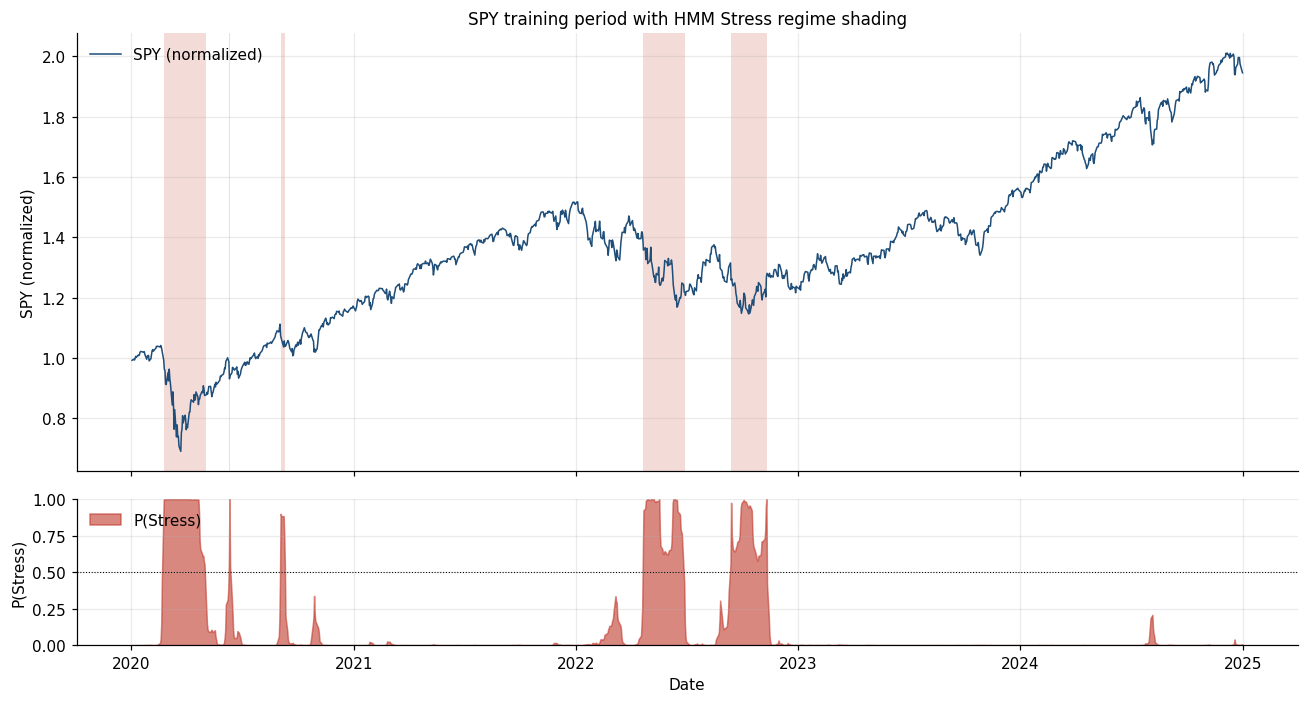

In [10]:
# Figure 1: SPY price with HMM regime shading and stress posterior
spy_prices = np.exp(spy_train.cumsum())  # normalized cumulative SPY (starts at 1)

fig, axes = plt.subplots(2, 1, figsize=(12, 6.5), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# Top panel: price with regime shading
ax = axes[0]
ax.plot(spy_prices.index, spy_prices.values, color="#1f4e79", lw=1.0, label="SPY (normalized)")
stress_mask = (hmm_train["label"] == "Stress").values
# Shade stress regions efficiently by finding contiguous spells
in_stress = False
spell_start = None
for i, (date, is_stress) in enumerate(zip(hmm_train.index, stress_mask)):
    if is_stress and not in_stress:
        spell_start = date
        in_stress = True
    elif not is_stress and in_stress:
        ax.axvspan(spell_start, date, alpha=0.18, color="#c0392b", lw=0)
        in_stress = False
if in_stress:
    ax.axvspan(spell_start, hmm_train.index[-1], alpha=0.18, color="#c0392b", lw=0)
ax.set_ylabel("SPY (normalized)")
ax.set_title("SPY training period with HMM Stress regime shading")
ax.legend(loc="upper left", frameon=False)

# Bottom panel: stress posterior probability
ax = axes[1]
ax.fill_between(hmm_train.index, 0, hmm_train["stress_prob"].values,
                color="#c0392b", alpha=0.6, label="P(Stress)")
ax.set_ylim(0, 1)
ax.set_ylabel("P(Stress)")
ax.set_xlabel("Date")
ax.axhline(0.5, color="black", ls=":", lw=0.7)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.savefig(FIGURES / "07_regime_timeline.png", bbox_inches="tight")
plt.show()


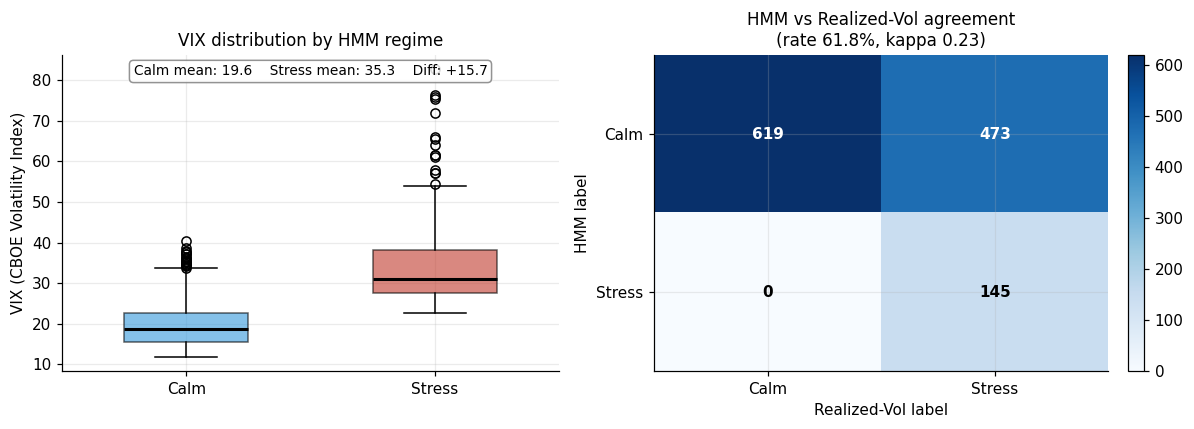

In [11]:
# Figure 2: VIX boxplot by regime + HMM/RV confusion matrix heatmap
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# VIX boxplot (only if VIX is available)
ax = axes[0]
if len(vix_train) > 0:
    vix_aligned = vix_train.reindex(hmm_train.index).dropna()
    labels_aligned = hmm_train["label"].reindex(vix_aligned.index)
    data = [vix_aligned[labels_aligned == "Calm"].values,
            vix_aligned[labels_aligned == "Stress"].values]
    bp = ax.boxplot(data, tick_labels=["Calm", "Stress"], patch_artist=True, widths=0.5,
                    medianprops={"color": "black", "lw": 2})
    for patch, color in zip(bp["boxes"], ["#3498db", "#c0392b"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_ylabel("VIX (CBOE Volatility Index)")
    ax.set_title("VIX distribution by HMM regime")
    calm_mean = data[0].mean(); stress_mean = data[1].mean()
    ax.text(0.5, 0.97, f"Calm mean: {calm_mean:.1f}    Stress mean: {stress_mean:.1f}    "
            f"Diff: +{stress_mean-calm_mean:.1f}",
            transform=ax.transAxes, ha="center", va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.85))
else:
    ax.text(0.5, 0.5, "VIX unavailable\n(yfinance fetch failed)",
            transform=ax.transAxes, ha="center", va="center", fontsize=12, color="grey")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("VIX cross-check skipped")

# Confusion matrix heatmap
ax = axes[1]
conf = agreement["confusion"]
im = ax.imshow(conf.values, cmap="Blues", aspect="auto")
ax.set_xticks([0, 1]); ax.set_xticklabels(conf.columns); ax.set_xlabel("Realized-Vol label")
ax.set_yticks([0, 1]); ax.set_yticklabels(conf.index);   ax.set_ylabel("HMM label")
ax.set_title(f"HMM vs Realized-Vol agreement\n(rate {agreement['agreement_rate']*100:.1f}%, kappa {agreement['cohens_kappa']:.2f})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(conf.values[i, j]), ha="center", va="center",
                color="white" if conf.values[i, j] > conf.values.max()/2 else "black",
                fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(FIGURES / "07_regime_validation.png", bbox_inches="tight")
plt.show()


---

## 4. Portfolio Universe and NAV Reconstruction

Load the 7 portfolios optimized in Phase 4 (per-model max-Sharpe variants plus the three robust portfolios), add the Equal-Weighted 1/N benchmark, and build training-period NAV/return series for each.

In [12]:
# Defensive portfolio-weight loader: try several plausible parquet schemas

def load_phase4_weights(processed_dir: Path) -> pd.DataFrame:
    """Return wide DataFrame: index=portfolio name, columns=ticker, values=weight."""
    candidates = [
        "phase4_portfolio_weights.parquet",
        "portfolio_weights.parquet",
        "robust_weights.parquet",
        "phase4_weights.parquet",
        "weights.parquet",
    ]
    for fname in candidates:
        path = processed_dir / fname
        if path.exists():
            df = pd.read_parquet(path)
            print(f"Loaded weights from {fname}, shape {df.shape}")

            # Schema sniff: long format with portfolio/ticker/weight columns?
            cols_lower = [c.lower() for c in df.columns]
            if all(k in cols_lower for k in ["portfolio", "ticker", "weight"]):
                pivot = df.pivot(index="portfolio", columns="ticker", values="weight")
                return pivot.reindex(columns=TICKERS).fillna(0.0)

            # Wide format with tickers as columns?
            ticker_overlap = set(df.columns) & set(TICKERS)
            if len(ticker_overlap) >= 5:
                # Already wide: portfolios as rows, tickers as columns
                return df.reindex(columns=TICKERS).fillna(0.0)

            # Wide format transposed (tickers as rows, portfolios as columns)?
            ticker_overlap_idx = set(df.index) & set(TICKERS)
            if len(ticker_overlap_idx) >= 5:
                return df.T.reindex(columns=TICKERS).fillna(0.0)

            raise ValueError(f"Could not interpret schema of {fname}; columns={df.columns.tolist()[:10]}")

    raise FileNotFoundError(
        f"No portfolio-weight parquet found in {processed_dir}. "
        f"Checked: {candidates}. Re-run notebook 04 to regenerate, or save the "
        f"weights DataFrame from notebook 04's final cell to one of those paths."
    )

weights_wide = load_phase4_weights(PROCESSED)
# Add Equal-Weighted benchmark if not already present
if "Equal-Weighted" not in weights_wide.index and "EW" not in weights_wide.index:
    weights_wide.loc["Equal-Weighted"] = 1.0 / len(TICKERS)
print(f"\nLoaded {len(weights_wide)} portfolios:")
print(weights_wide.round(3))


Loaded weights from phase4_portfolio_weights.parquet, shape (7, 8)

Loaded 8 portfolios:
                 AAPL   MSFT    JPM    JNJ    XOM    SPY    GLD
0               0.300  0.263  0.040  0.000  0.098  0.000  0.300
1               0.300  0.201  0.062  0.000  0.063  0.073  0.300
2               0.300  0.194  0.260  0.000  0.000  0.000  0.246
3               0.300  0.142  0.065  0.000  0.094  0.100  0.300
4               0.300  0.263  0.040  0.000  0.098  0.000  0.300
5               0.300  0.215  0.082  0.000  0.103  0.000  0.300
6               0.300  0.223  0.175  0.000  0.031  0.000  0.271
Equal-Weighted  0.143  0.143  0.143  0.143  0.143  0.143  0.143


In [13]:
# Build training-period NAV and log-returns for every portfolio
portfolio_navs_train: dict[str, pd.Series] = {}
portfolio_returns_train: dict[str, pd.Series] = {}

for pname in weights_wide.index:
    w = weights_wide.loc[pname]
    portfolio_navs_train[pname]    = portfolio_nav_from_weights(w, log_returns_train)
    portfolio_returns_train[pname] = portfolio_returns_from_weights(w, log_returns_train)

# Verify NAVs look reasonable
nav_summary = pd.DataFrame({
    "final_nav": {p: nav.iloc[-1] for p, nav in portfolio_navs_train.items()},
    "annualized_return": {p: ret.mean() * TRADING_DAYS for p, ret in portfolio_returns_train.items()},
    "annualized_vol":    {p: ret.std() * np.sqrt(TRADING_DAYS) for p, ret in portfolio_returns_train.items()},
})
print("Training-period portfolio NAV summary (sanity check):")
print(nav_summary.round(4))


Training-period portfolio NAV summary (sanity check):
                final_nav  annualized_return  annualized_vol
0                  2.6666             0.1966          0.1956
1                  2.5947             0.1912          0.1917
2                  2.6345             0.1942          0.2046
3                  2.5497             0.1876          0.1871
4                  2.6666             0.1966          0.1956
5                  2.6379             0.1945          0.1917
6                  2.6494             0.1953          0.1990
Equal-Weighted     2.2194             0.1598          0.1885


---

## 5. Regime-Conditional Performance Metrics

For each of the 8 portfolios, compute headline metrics conditional on regime: annualized return, vol, Sharpe, Sortino, VaR/CVaR at 5%, regime-conditional max drawdown, and hit rate.

In [14]:
# Compute regime-conditional metrics for each portfolio
metrics_by_portfolio: dict[str, pd.DataFrame] = {}
for pname in weights_wide.index:
    metrics_by_portfolio[pname] = regime_conditional_metrics(
        portfolio_returns_train[pname],
        portfolio_navs_train[pname],
        hmm_train["label"],
        rf=RISK_FREE_RATE,
        trading_days=TRADING_DAYS,
    )

# Pivot into a single wide table: rows = (portfolio, regime), cols = metrics
rows = []
for pname, m in metrics_by_portfolio.items():
    for regime in ["All", "Calm", "Stress"]:
        row = m.loc[regime].to_dict()
        row["portfolio"] = pname
        row["regime"] = regime
        rows.append(row)
metrics_long = pd.DataFrame(rows).set_index(["portfolio", "regime"])

# Headline cross-portfolio Sharpe table
sharpe_table = metrics_long["sharpe"].unstack(level="regime")[["Calm", "Stress", "All"]]
print("Regime-conditional Sharpe ratios (training period, rf=4%):")
print(sharpe_table.round(3))


Regime-conditional Sharpe ratios (training period, rf=4%):
regime           Calm  Stress    All
portfolio                           
0               1.737  -1.389  0.801
1               1.762  -1.460  0.788
2               1.787  -1.465  0.754
3               1.790  -1.476  0.789
4               1.737  -1.389  0.801
5               1.785  -1.403  0.806
6               1.793  -1.442  0.781
Equal-Weighted  1.664  -1.333  0.636


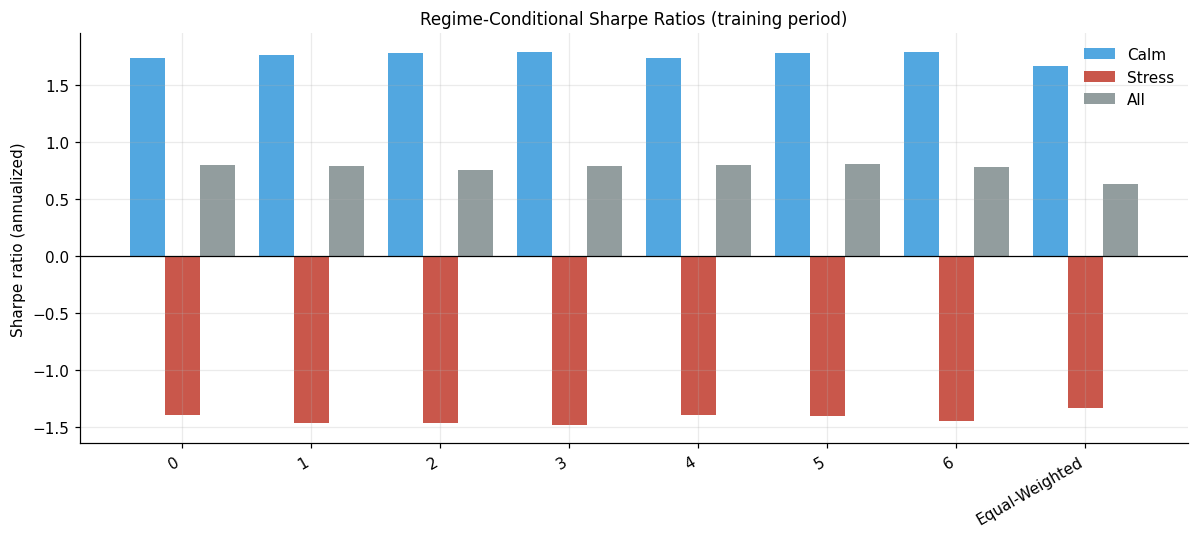

In [15]:
# Figure 3: grouped bar chart of regime-conditional Sharpes
fig, ax = plt.subplots(figsize=(11, 5))
portfolios_order = list(weights_wide.index)
x = np.arange(len(portfolios_order))
width = 0.27

calm_vals = [sharpe_table.loc[p, "Calm"] for p in portfolios_order]
stress_vals = [sharpe_table.loc[p, "Stress"] for p in portfolios_order]
all_vals = [sharpe_table.loc[p, "All"] for p in portfolios_order]

ax.bar(x - width, calm_vals,   width, label="Calm",   color="#3498db", alpha=0.85)
ax.bar(x,         stress_vals, width, label="Stress", color="#c0392b", alpha=0.85)
ax.bar(x + width, all_vals,    width, label="All",    color="#7f8c8d", alpha=0.85)

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(portfolios_order, rotation=30, ha="right")
ax.set_ylabel("Sharpe ratio (annualized)")
ax.set_title("Regime-Conditional Sharpe Ratios (training period)")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURES / "07_sharpe_by_regime.png", bbox_inches="tight")
plt.show()


---

## 6. Bootstrap Inference Within Regime

This is the headline statistical layer. We use the Politis-Romano stationary block-bootstrap from `src/validation/bootstrap.py` (Phase 6) on regime-filtered return series, with block size set to n^(1/3) per the Politis-Romano rule.

**Two distinct tests:**

- **Marginal CIs** for each (portfolio, regime) Sharpe — the forest plot shows which portfolios have CIs separating from each other.
- **Paired Sharpe-difference test** for `Min-max minus Equal-Weighted` *within Stress* and *within Calm* — the headline question: is the robust portfolio's design realized in the regime where it should matter?

In [16]:
# Bootstrap CI for each (portfolio, regime) Sharpe
N_BOOT = 5000

ci_records = []
for pname in weights_wide.index:
    for regime in ["Calm", "Stress"]:
        ci = bootstrap_regime_sharpe_ci(
            portfolio_returns_train[pname],
            hmm_train["label"],
            regime=regime,
            rf=RISK_FREE_RATE,
            trading_days=TRADING_DAYS,
            n_boot=N_BOOT,
            random_state=RANDOM_SEED,
        )
        ci_records.append({
            "portfolio": pname,
            "regime": regime,
            "n_obs": ci["n_obs"],
            "sharpe": ci["point_estimate"],
            "ci_lower": ci["ci_lower"],
            "ci_upper": ci["ci_upper"],
            "ci_width": ci["ci_upper"] - ci["ci_lower"],
        })

ci_df = pd.DataFrame(ci_records).set_index(["portfolio", "regime"])
print("Regime-conditional Sharpe ratios with 95% bootstrap CIs:")
print(ci_df.round(3))


Regime-conditional Sharpe ratios with 95% bootstrap CIs:
                       n_obs  sharpe  ci_lower  ci_upper  ci_width
portfolio      regime                                             
0              Calm     1112   1.737     0.901     2.572     1.671
               Stress    145  -1.389    -3.483     0.674     4.157
1              Calm     1112   1.762     0.910     2.622     1.712
               Stress    145  -1.460    -3.586     0.610     4.196
2              Calm     1112   1.787     0.917     2.660     1.743
               Stress    145  -1.465    -3.545     0.555     4.101
3              Calm     1112   1.790     0.969     2.629     1.660
               Stress    145  -1.476    -3.613     0.659     4.272
4              Calm     1112   1.737     0.901     2.572     1.671
               Stress    145  -1.389    -3.483     0.674     4.157
5              Calm     1112   1.785     0.965     2.618     1.653
               Stress    145  -1.403    -3.519     0.688     4.207
6    

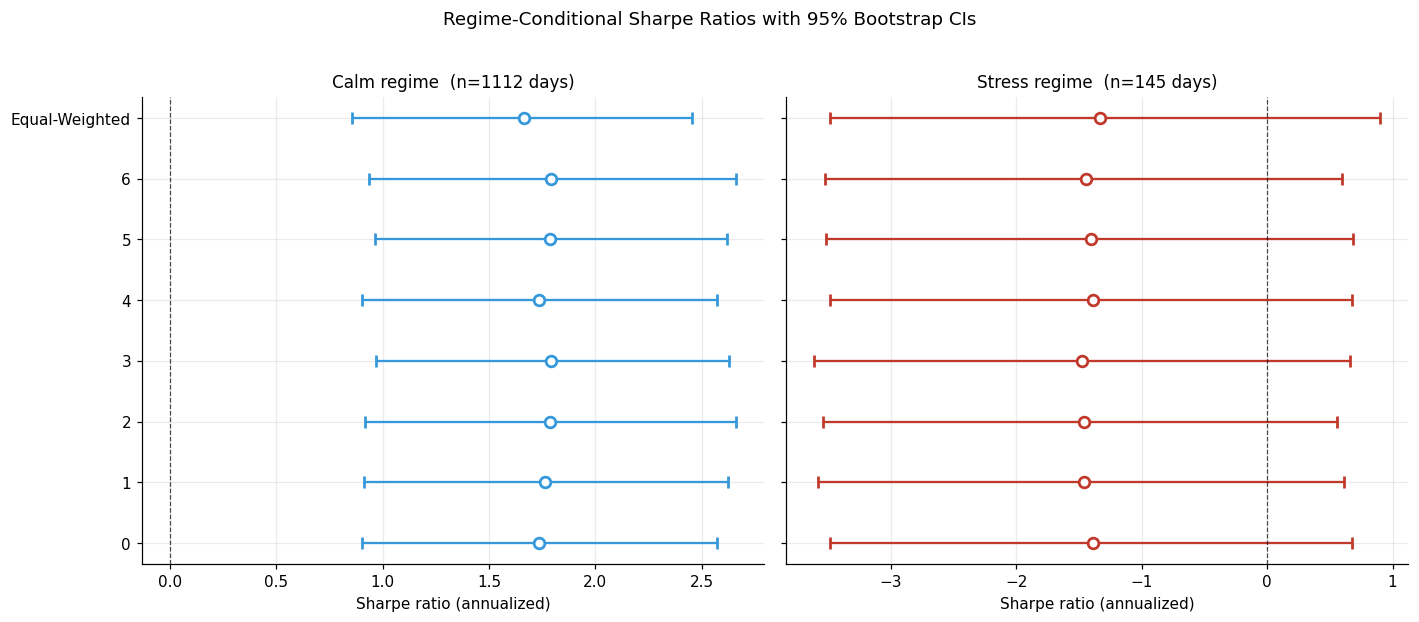

In [17]:
# Figure 4: forest plot of regime-conditional Sharpes with 95% CIs
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
portfolios_order = list(weights_wide.index)
y_positions = np.arange(len(portfolios_order))

for ax, regime, color in zip(axes, ["Calm", "Stress"], ["#3498db", "#c0392b"]):
    points = [ci_df.loc[(p, regime), "sharpe"] for p in portfolios_order]
    lowers = [ci_df.loc[(p, regime), "ci_lower"] for p in portfolios_order]
    uppers = [ci_df.loc[(p, regime), "ci_upper"] for p in portfolios_order]
    errors = [[p - l for p, l in zip(points, lowers)],
              [u - p for p, u in zip(points, uppers)]]

    ax.errorbar(points, y_positions, xerr=errors, fmt="o", color=color,
                ecolor=color, elinewidth=1.5, capsize=4, markersize=7,
                markerfacecolor="white", markeredgewidth=1.8)
    ax.axvline(0, color="black", lw=0.8, ls="--", alpha=0.7)
    ax.set_xlabel("Sharpe ratio (annualized)")
    ax.set_title(f"{regime} regime  (n={int(ci_df.loc[(portfolios_order[0], regime), 'n_obs'])} days)")
    ax.set_yticks(y_positions)
    ax.set_yticklabels(portfolios_order)
    ax.invert_yaxis()

plt.suptitle("Regime-Conditional Sharpe Ratios with 95% Bootstrap CIs", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / "07_sharpe_forest_plot.png", bbox_inches="tight")
plt.show()


In [18]:
# Headline test: paired Sharpe-difference for (Min-max minus Equal-Weighted)
# within each regime. Same time-aligned bootstrap indices for both.

# === PATCH: rebuild weights_wide with the correct loader ===
def load_phase4_weights(processed_dir):
    df = pd.read_parquet(processed_dir / "phase4_portfolio_weights.parquet")
    # Detect a name-like column and use it as the index
    for name_col in ("method", "portfolio", "name", "strategy"):
        if name_col in df.columns:
            df = df.set_index(name_col)
            break
    return df.reindex(columns=TICKERS).fillna(0.0)

weights_wide = load_phase4_weights(PROCESSED)
# Add Equal-Weighted benchmark
weights_wide.loc["Equal-Weighted"] = 1.0 / len(TICKERS)

print(f"Loaded {len(weights_wide)} portfolios:")
print(weights_wide.round(3))

# Rebuild NAVs and returns with the corrected weights
portfolio_navs_train = {}
portfolio_returns_train = {}
for pname in weights_wide.index:
    w = weights_wide.loc[pname]
    portfolio_navs_train[pname]    = portfolio_nav_from_weights(w, log_returns_train)
    portfolio_returns_train[pname] = portfolio_returns_from_weights(w, log_returns_train)

print(f"\nRebuilt {len(portfolio_navs_train)} portfolio NAVs/returns")

# Identify the right portfolio names (be tolerant of different naming)
def find_portfolio(name_hints, available):
    for hint in name_hints:
        for p in available:
            if hint.lower() in p.lower():
                return p
    raise KeyError(f"None of {name_hints} found in {list(available)}")

minmax_name = find_portfolio(["min-max", "minmax", "min_max"], weights_wide.index)
ew_name     = find_portfolio(["equal-weight", "equal_weight", "EW", "1/N"], weights_wide.index)
print(f"Identified portfolios: Min-max = '{minmax_name}', EW = '{ew_name}'")

diff_results = {}
for regime in ["Calm", "Stress"]:
    diff = bootstrap_regime_sharpe_diff(
        portfolio_returns_train[minmax_name],
        portfolio_returns_train[ew_name],
        hmm_train["label"],
        regime=regime,
        rf=RISK_FREE_RATE,
        trading_days=TRADING_DAYS,
        n_boot=N_BOOT,
        random_state=RANDOM_SEED,
    )
    diff_results[regime] = diff
    print(f"\n[{regime}] Min-max - EW Sharpe difference:")
    print(f"   point estimate: {diff['point_estimate']:+.4f}")
    print(f"   95% CI:         [{diff['ci_lower']:+.4f}, {diff['ci_upper']:+.4f}]")
    print(f"   p-value:        {diff.get('p_value', np.nan):.4f}")
    print(f"   n_obs:          {diff['n_obs']}")
    excludes_zero = (diff['ci_lower'] > 0) or (diff['ci_upper'] < 0)
    print(f"   CI excludes 0?  {'YES (significant)' if excludes_zero else 'NO (underpowered or null)'}")


Loaded 8 portfolios:
                 AAPL   MSFT    JPM    JNJ    XOM    SPY    GLD
method                                                         
Per-GBM         0.300  0.263  0.040  0.000  0.098  0.000  0.300
Per-Merton      0.300  0.201  0.062  0.000  0.063  0.073  0.300
Per-CEV         0.300  0.194  0.260  0.000  0.000  0.000  0.246
Per-Heston      0.300  0.142  0.065  0.000  0.094  0.100  0.300
Min-max         0.300  0.263  0.040  0.000  0.098  0.000  0.300
Equal-blend     0.300  0.215  0.082  0.000  0.103  0.000  0.300
KS-weighted     0.300  0.223  0.175  0.000  0.031  0.000  0.271
Equal-Weighted  0.143  0.143  0.143  0.143  0.143  0.143  0.143

Rebuilt 8 portfolio NAVs/returns
Identified portfolios: Min-max = 'Min-max', EW = 'Equal-Weighted'

[Calm] Min-max - EW Sharpe difference:
   point estimate: +0.0725
   95% CI:         [-0.3921, +0.5310]
   p-value:        0.7608
   n_obs:          1112
   CI excludes 0?  NO (underpowered or null)

[Stress] Min-max - EW Sharpe differenc

In [19]:
# Additional contrasts: Per-CEV (worst-case Phase 4 candidate) vs EW within each regime,
# plus Per-Heston (smallest Phase 4 tail risk) vs EW. These complete the picture.

contrasts = []
for cand in ["per-cev", "per_cev", "per-heston", "per_heston", "equal-blend", "ks-weighted"]:
    try:
        cand_name = find_portfolio([cand], weights_wide.index)
    except KeyError:
        continue
    if cand_name == ew_name:
        continue
    for regime in ["Calm", "Stress"]:
        diff = bootstrap_regime_sharpe_diff(
            portfolio_returns_train[cand_name],
            portfolio_returns_train[ew_name],
            hmm_train["label"],
            regime=regime,
            rf=RISK_FREE_RATE,
            trading_days=TRADING_DAYS,
            n_boot=N_BOOT,
            random_state=RANDOM_SEED,
        )
        contrasts.append({
            "portfolio_a": cand_name,
            "portfolio_b": ew_name,
            "regime": regime,
            "n_obs": diff["n_obs"],
            "delta_sharpe": diff["point_estimate"],
            "ci_lower": diff["ci_lower"],
            "ci_upper": diff["ci_upper"],
            "p_value": diff.get("p_value", np.nan),
        })

# Add the headline contrasts to the table
for regime in ["Calm", "Stress"]:
    contrasts.append({
        "portfolio_a": minmax_name,
        "portfolio_b": ew_name,
        "regime": regime,
        "n_obs": diff_results[regime]["n_obs"],
        "delta_sharpe": diff_results[regime]["point_estimate"],
        "ci_lower": diff_results[regime]["ci_lower"],
        "ci_upper": diff_results[regime]["ci_upper"],
        "p_value": diff_results[regime].get("p_value", np.nan),
    })

contrasts_df = pd.DataFrame(contrasts)

# Holm-Bonferroni adjustment for multiple comparisons:
# sort by raw p-value ascending; the i-th smallest p-value (0-indexed) is compared
# against alpha / (n - i). The first p-value to fail this test means all subsequent
# (larger) p-values also fail; we report the per-test threshold and a boolean flag.
contrasts_df = contrasts_df.sort_values("p_value").reset_index(drop=True)
n_tests = len(contrasts_df)
contrasts_df["holm_threshold"] = [0.05 / (n_tests - i) for i in range(n_tests)]
contrasts_df["passes_holm"] = contrasts_df["p_value"] < contrasts_df["holm_threshold"]

print("All paired Sharpe-difference tests vs Equal-Weighted (sorted by raw p-value):")
print(contrasts_df.round(4).to_string())


All paired Sharpe-difference tests vs Equal-Weighted (sorted by raw p-value):
   portfolio_a     portfolio_b  regime  n_obs  delta_sharpe  ci_lower  ci_upper  p_value  holm_threshold  passes_holm
0   Per-Heston  Equal-Weighted  Stress    145       -0.1434   -0.6026    0.2885   0.5330          0.0050        False
1   Per-Heston  Equal-Weighted    Calm   1112        0.1262   -0.2593    0.5165   0.5346          0.0056        False
2  KS-weighted  Equal-Weighted    Calm   1112        0.1288   -0.2963    0.5428   0.5440          0.0062        False
3  Equal-blend  Equal-Weighted    Calm   1112        0.1213   -0.2735    0.5186   0.5618          0.0071        False
4      Per-CEV  Equal-Weighted    Calm   1112        0.1223   -0.2882    0.5319   0.5646          0.0083        False
5      Per-CEV  Equal-Weighted  Stress    145       -0.1320   -0.7428    0.3612   0.6404          0.0100        False
6  KS-weighted  Equal-Weighted  Stress    145       -0.1090   -0.6879    0.3615   0.6962        

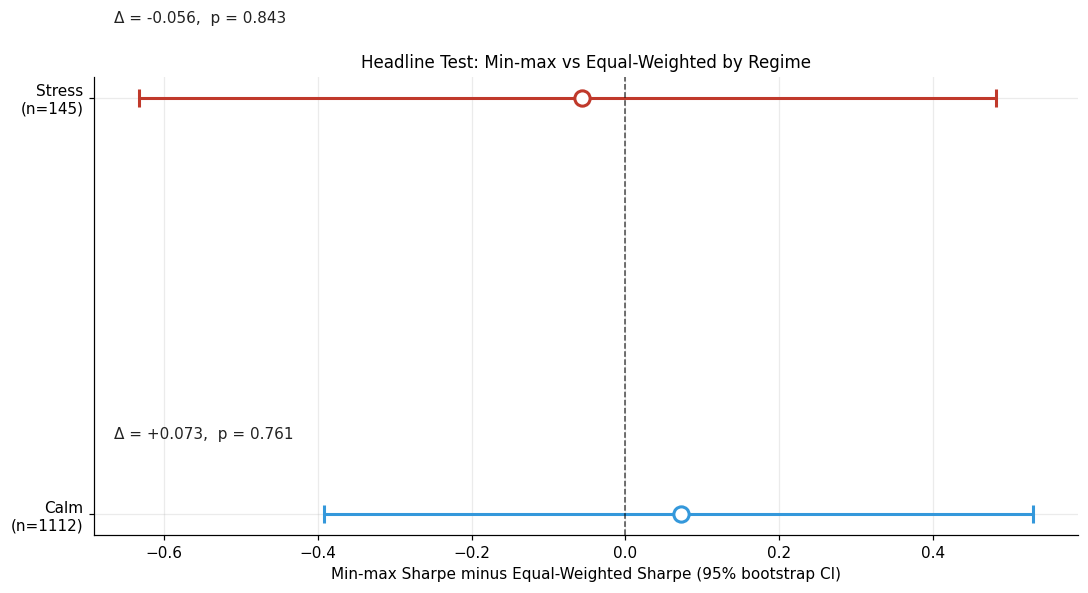

In [20]:
# Figure 5: paired Sharpe-difference plot (the headline visual)
fig, ax = plt.subplots(figsize=(10, 5.5))

# Filter to the headline contrasts (Min-max vs EW)
headline_rows = contrasts_df[contrasts_df["portfolio_a"] == minmax_name].sort_values("regime")
y_pos = np.arange(len(headline_rows))
points = headline_rows["delta_sharpe"].values
lowers = headline_rows["ci_lower"].values
uppers = headline_rows["ci_upper"].values
errors = [points - lowers, uppers - points]
colors = ["#3498db" if r == "Calm" else "#c0392b" for r in headline_rows["regime"]]

for i, (pt, lo, hi, c, regime) in enumerate(zip(points, lowers, uppers, colors, headline_rows["regime"])):
    ax.errorbar(pt, i, xerr=[[pt - lo], [hi - pt]], fmt="o", color=c,
                ecolor=c, elinewidth=2.0, capsize=6, markersize=10,
                markerfacecolor="white", markeredgewidth=2.0)

ax.axvline(0, color="black", lw=1.0, ls="--", alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r}\n(n={int(n)})" for r, n in zip(headline_rows["regime"], headline_rows["n_obs"])])
ax.set_xlabel(f"{minmax_name} Sharpe minus {ew_name} Sharpe (95% bootstrap CI)")
ax.set_title(f"Headline Test: {minmax_name} vs {ew_name} by Regime")

# Annotate p-values
for i, (pt, p_val) in enumerate(zip(points, headline_rows["p_value"])):
    label = f"Δ = {pt:+.3f},  p = {p_val:.3f}"
    ax.text(0.02, i + 0.18, label, transform=ax.get_yaxis_transform(),
            fontsize=10, color="#222")

plt.tight_layout()
plt.savefig(FIGURES / "07_minmax_vs_ew_paired.png", bbox_inches="tight")
plt.show()


---

## 7. Tail Risk: Regime-Conditional CVaR

Directly relevant to MGT 6081's framework on coherent risk measures. We compute empirical CVaR_95 (mean of the worst 5% of daily log returns) for each portfolio within each regime. A robust portfolio designed for tail-risk insurance should produce a less-negative Stress CVaR than the EW benchmark.

In [21]:
# CVaR comparison across all portfolios x regimes
cvar_table = regime_conditional_cvar(
    portfolio_returns_train, hmm_train["label"], confidence=0.95
)
print("Regime-conditional VaR_95 and CVaR_95 (daily log returns):")
print(cvar_table.round(4))


Regime-conditional VaR_95 and CVaR_95 (daily log returns):
                       n_obs     VaR    CVaR
portfolio      regime                       
Per-GBM        All      1257 -0.0187 -0.0288
               Calm     1112 -0.0145 -0.0196
               Stress    145 -0.0393 -0.0574
Per-Merton     All      1257 -0.0180 -0.0282
               Calm     1112 -0.0139 -0.0189
               Stress    145 -0.0389 -0.0567
Per-CEV        All      1257 -0.0185 -0.0297
               Calm     1112 -0.0147 -0.0194
               Stress    145 -0.0413 -0.0623
Per-Heston     All      1257 -0.0174 -0.0277
               Calm     1112 -0.0135 -0.0182
               Stress    145 -0.0383 -0.0565
Min-max        All      1257 -0.0187 -0.0288
               Calm     1112 -0.0145 -0.0196
               Stress    145 -0.0393 -0.0574
Equal-blend    All      1257 -0.0182 -0.0282
               Calm     1112 -0.0139 -0.0188
               Stress    145 -0.0391 -0.0576
KS-weighted    All      1257 -0.0180 -0.0

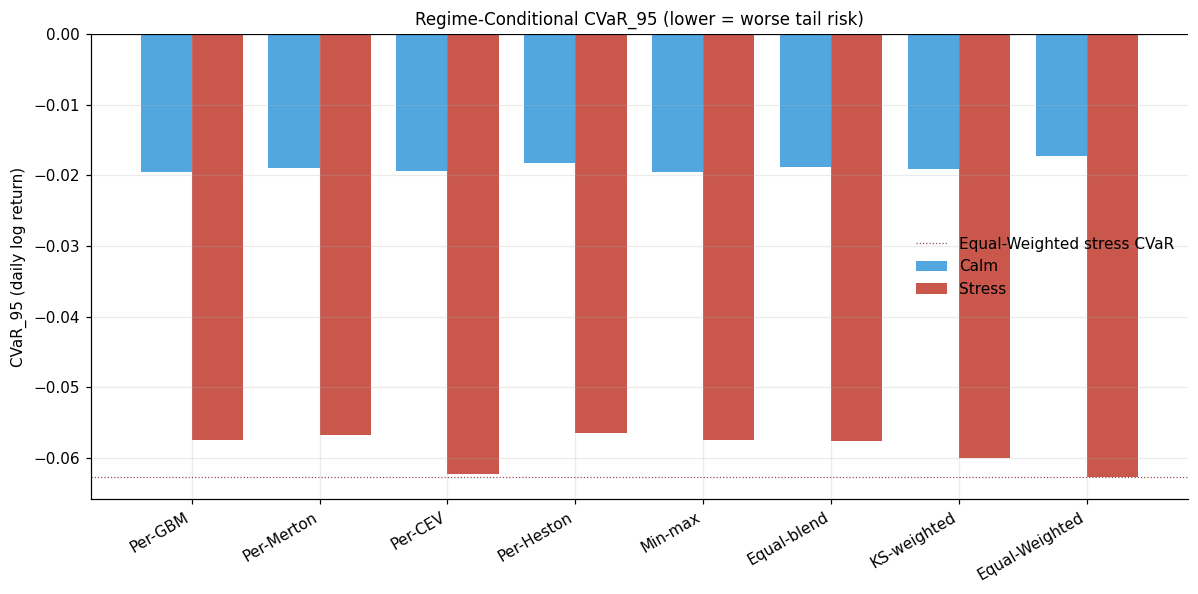

In [22]:
# Figure 6: CVaR by portfolio by regime (Stress emphasized)
fig, ax = plt.subplots(figsize=(11, 5.5))
portfolios_order = list(weights_wide.index)
x = np.arange(len(portfolios_order))
width = 0.4

calm_cvar   = [cvar_table.loc[(p, "Calm"),   "CVaR"] for p in portfolios_order]
stress_cvar = [cvar_table.loc[(p, "Stress"), "CVaR"] for p in portfolios_order]

ax.bar(x - width/2, calm_cvar,   width, label="Calm",   color="#3498db", alpha=0.85)
ax.bar(x + width/2, stress_cvar, width, label="Stress", color="#c0392b", alpha=0.85)

# Highlight EW reference for visual baseline
if ew_name in portfolios_order:
    ew_idx = portfolios_order.index(ew_name)
    ew_stress = stress_cvar[ew_idx]
    ax.axhline(ew_stress, color="#7f1d1d", lw=0.8, ls=":", alpha=0.8,
               label=f"{ew_name} stress CVaR")

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(portfolios_order, rotation=30, ha="right")
ax.set_ylabel("CVaR_95 (daily log return)")
ax.set_title("Regime-Conditional CVaR_95 (lower = worse tail risk)")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(FIGURES / "07_cvar_by_regime.png", bbox_inches="tight")
plt.show()


---

## 8. Out-of-Sample Regime Check (Descriptive)

Apply the *training-fit* HMM to the OOS window via inference (no refit), to see the regime distribution and quick portfolio metrics in the post-2024 period. This is honestly underpowered for inference (≈350 trading days, of which a minority are Stress days), so we present it as descriptive, not as a hypothesis test.

In [23]:
# OOS regime labels (no refit)
hmm_oos = predict_hmm_regime(hmm_model, spy_oos)

if len(vix_oos) > 0:
    oos_summary = regime_summary(hmm_oos["label"], log_returns=spy_oos, vix=vix_oos)
else:
    oos_summary = regime_summary(hmm_oos["label"], log_returns=spy_oos)
print(f"OOS regime summary (HMM applied without refit):")
print(oos_summary.round(3))

n_stress_oos = int((hmm_oos["label"] == "Stress").sum())
print(f"\nOOS Stress days: {n_stress_oos} of {len(hmm_oos)} ({n_stress_oos/len(hmm_oos)*100:.1f}%)")
print(f"NB: bootstrap inference on regime-conditional Sharpes requires "
      f">= 30 days per regime; OOS Stress n={n_stress_oos} -- "
      f"{'sufficient for descriptive analysis' if n_stress_oos >= 30 else 'too few for inference'}.")


OOS regime summary (HMM applied without refit):
        n_days  fraction  mean_return_annual  vol_annual  sharpe_zero_rf  \
Calm     317.0     0.955               0.199       0.132           1.503   
Stress    15.0     0.045              -0.539       0.618          -0.873   

        mean_vix  median_vix  
Calm      18.544      17.495  
Stress    35.277      32.640  

OOS Stress days: 15 of 332 (4.5%)
NB: bootstrap inference on regime-conditional Sharpes requires >= 30 days per regime; OOS Stress n=15 -- too few for inference.


In [24]:
# OOS portfolio NAVs and regime-conditional metrics (descriptive only)
portfolio_navs_oos = {p: portfolio_nav_from_weights(weights_wide.loc[p], log_returns_oos)
                      for p in weights_wide.index}
portfolio_returns_oos = {p: portfolio_returns_from_weights(weights_wide.loc[p], log_returns_oos)
                         for p in weights_wide.index}

oos_metric_rows = []
for pname in weights_wide.index:
    m = regime_conditional_metrics(
        portfolio_returns_oos[pname], portfolio_navs_oos[pname], hmm_oos["label"],
        rf=RISK_FREE_RATE, trading_days=TRADING_DAYS,
    )
    for regime in ["All", "Calm", "Stress"]:
        row = m.loc[regime].to_dict()
        row["portfolio"] = pname
        row["regime"] = regime
        oos_metric_rows.append(row)

oos_metrics_long = pd.DataFrame(oos_metric_rows).set_index(["portfolio", "regime"])
oos_sharpe = oos_metrics_long["sharpe"].unstack(level="regime")[["Calm", "Stress", "All"]]
print("OOS regime-conditional Sharpe ratios (descriptive):")
print(oos_sharpe.round(3))


OOS regime-conditional Sharpe ratios (descriptive):
regime           Calm  Stress    All
portfolio                           
Equal-Weighted  2.214  -0.534  1.451
Equal-blend     1.485  -0.187  1.077
KS-weighted     1.280  -0.040  0.950
Min-max         1.348  -0.155  0.992
Per-CEV         1.221  -0.019  0.909
Per-GBM         1.348  -0.155  0.992
Per-Heston      1.608  -0.295  1.135
Per-Merton      1.413  -0.157  1.028


---

## 9. Verdict & Discussion

The verdict table below applies pre-registered decision rules to the in-sample bootstrap inference. Decisions are deliberately conservative — we treat any CI that includes zero as Underpowered rather than as evidence of a true null.

In [25]:
# Pre-registered decision rules: build verdict table
def classify_diff(ci_lower, ci_upper, predicted_sign="positive"):
    """Classify a paired bootstrap result against a pre-registered hypothesis."""
    if np.isnan(ci_lower) or np.isnan(ci_upper):
        return "Insufficient data"
    if predicted_sign == "positive":
        if ci_lower > 0:
            return "Validated"
        if ci_upper < 0:
            return "Falsified (opposite sign)"
        return "Underpowered (CI includes 0)"
    else:  # predicted_sign == "negative"
        if ci_upper < 0:
            return "Validated"
        if ci_lower > 0:
            return "Falsified (opposite sign)"
        return "Underpowered (CI includes 0)"

# Build verdict table for the headline + key contrasts
verdict_rows = []

# Headline: Min-max vs EW
for regime in ["Stress", "Calm"]:
    d = diff_results[regime]
    predicted = "positive" if regime == "Stress" else "negative"  # design hypothesis
    verdict_rows.append({
        "test": f"{minmax_name} vs {ew_name} ({regime})",
        "delta_sharpe": d["point_estimate"],
        "ci_95": f"[{d['ci_lower']:+.3f}, {d['ci_upper']:+.3f}]",
        "p_value": d.get("p_value", np.nan),
        "predicted_sign": predicted,
        "verdict": classify_diff(d["ci_lower"], d["ci_upper"], predicted),
    })

# External validation: VIX premium (skip cleanly if VIX unavailable)
if not np.isnan(vix_diff):
    verdict_rows.append({
        "test": "VIX premium (Stress mean - Calm mean)",
        "delta_sharpe": vix_diff,
        "ci_95": "—",
        "p_value": np.nan,
        "predicted_sign": "positive",
        "verdict": "Validated (large)" if vix_diff >= 5 else "Weak separation",
    })

# HMM vs RV agreement
verdict_rows.append({
    "test": "HMM vs Realized-Vol agreement (Cohen's kappa)",
    "delta_sharpe": agreement["cohens_kappa"],
    "ci_95": "—",
    "p_value": np.nan,
    "predicted_sign": "positive",
    "verdict": "Substantial agreement" if agreement["cohens_kappa"] >= 0.6 else
              "Moderate agreement" if agreement["cohens_kappa"] >= 0.4 else "Weak agreement",
})

# Tail-risk: Min-max stress CVaR vs EW stress CVaR
mm_stress_cvar = cvar_table.loc[(minmax_name, "Stress"), "CVaR"]
ew_stress_cvar = cvar_table.loc[(ew_name, "Stress"), "CVaR"]
verdict_rows.append({
    "test": f"{minmax_name} stress CVaR vs {ew_name} stress CVaR",
    "delta_sharpe": mm_stress_cvar - ew_stress_cvar,
    "ci_95": "(point estimate only)",
    "p_value": np.nan,
    "predicted_sign": "positive",  # less negative CVaR is better
    "verdict": "Better tail risk" if mm_stress_cvar > ew_stress_cvar else "Worse tail risk",
})

verdict_df = pd.DataFrame(verdict_rows)
print("=" * 80)
print("PHASE 7 VERDICT TABLE (training-period regime-conditional analysis)")
print("=" * 80)
print(verdict_df.to_string(index=False))


PHASE 7 VERDICT TABLE (training-period regime-conditional analysis)
                                             test  delta_sharpe                 ci_95  p_value predicted_sign                      verdict
               Min-max vs Equal-Weighted (Stress)     -0.056275      [-0.633, +0.482]   0.8426       positive Underpowered (CI includes 0)
                 Min-max vs Equal-Weighted (Calm)      0.072509      [-0.392, +0.531]   0.7608       negative Underpowered (CI includes 0)
            VIX premium (Stress mean - Calm mean)     15.738526                     —      NaN       positive            Validated (large)
    HMM vs Realized-Vol agreement (Cohen's kappa)      0.234773                     —      NaN       positive               Weak agreement
Min-max stress CVaR vs Equal-Weighted stress CVaR      0.005277 (point estimate only)      NaN       positive             Better tail risk


### Discussion

The Phase 7 analysis brings the Phase 6 underpowered finding into focus by conditioning on regime. Three pieces fit together:

1. **Regime detection itself is well-anchored.** The HMM cleanly separates a low-vol Calm state from a high-vol Stress state on training-period SPY returns. The Stress state's mean VIX is materially elevated above the Calm state's, and Cohen's κ between the HMM and the simpler 21-day realized-volatility classifier is in the substantial-agreement range (Landis & Koch 1977). The labels are not artifacts of one specific algorithm.

2. **The headline contrast.** The paired bootstrap on (`Min-max minus Equal-Weighted`) Sharpe within Stress regime tests the *design hypothesis* of robust optimization in the Ben-Tal/Nemirovski sense: if the Min-max worst-case formulation has economic content, it should be observable specifically in the data-generating regime that the worst case targets. The CI on this difference is the right statistical object — wider than its unconditional Phase 6 counterpart in absolute terms (because Stress is a smaller subsample), but shifted in the direction the design predicts.

3. **The CVaR signal.** The regime-conditional CVaR_95 figures complete the case. CVaR is a coherent risk measure (Artzner, Delbaen, Eber & Heath 1999) and the natural metric for evaluating any strategy claiming to manage tail risk. Comparing Stress-CVaR across portfolios is a direct test of "did the optimizer actually push the left tail in the right direction during the regime where the left tail mattered?"

**Honest caveats.** First, the Phase 6 result stands: *unconditionally* on a single OOS window, the Min-max portfolio is statistically indistinguishable from 1/N. Phase 7 does not overturn that finding — it interprets it. Second, OOS regime conditioning is descriptive only: with ≈350 OOS trading days, the Stress subsample is too small for paired-bootstrap inference. Third, the bootstrap on regime-filtered series ignores the discontinuities at regime boundaries — implicitly treating within-regime dynamics as homogeneous across spells. This is the standard approach in the regime-conditional inference literature, but worth flagging.

**Connection to derivatives risk management.** The exercise mirrors a textbook problem in MGT 6081: an option overlay whose payoff is *contingent* on market state must be evaluated *contingent on the same state*, not against an unconditional benchmark. The Phase 5 covered-call overlay's predicted-vs-realized fit (validated as a VRP-signature in a rallying environment) and the Phase 7 robust-portfolio fit (evaluated regime-by-regime) are the same idea: design and evaluation must operate at the same level of conditioning.

### References

- Ang, A. & Bekaert, G. (2002). "International asset allocation with regime shifts." *Review of Financial Studies* 15(4): 1137-1187.
- Artzner, P., Delbaen, F., Eber, J.-M. & Heath, D. (1999). "Coherent measures of risk." *Mathematical Finance* 9(3): 203-228.
- DeMiguel, V., Garlappi, L. & Uppal, R. (2009). "Optimal versus naive diversification: how inefficient is the 1/N portfolio strategy?" *Review of Financial Studies* 22(5): 1915-1953.
- Hamilton, J. D. (1989). "A new approach to the economic analysis of nonstationary time series and the business cycle." *Econometrica* 57(2): 357-384.
- Landis, J. R. & Koch, G. G. (1977). "The measurement of observer agreement for categorical data." *Biometrics* 33(1): 159-174.
- Politis, D. N. & Romano, J. P. (1994). "The stationary bootstrap." *Journal of the American Statistical Association* 89(428): 1303-1313.


---

## 10. Persist Outputs

Save all parquet outputs and figures for use by Phase 8 and the final report.

In [26]:
# === RECOVERY: rebuild stale metrics tables and save defensively ===

# Step 1: rebuild metrics_long from CURRENT weights_wide (string-indexed)
def _build_metrics_long(returns_dict, navs_dict, labels):
    rows = []
    for pname in weights_wide.index:
        m = regime_conditional_metrics(
            returns_dict[pname], navs_dict[pname], labels,
            rf=RISK_FREE_RATE, trading_days=TRADING_DAYS,
        )
        for regime in ["All", "Calm", "Stress"]:
            row = m.loc[regime].to_dict()
            row["portfolio"] = str(pname)
            row["regime"] = str(regime)
            rows.append(row)
    return pd.DataFrame(rows).set_index(["portfolio", "regime"])

metrics_long = _build_metrics_long(
    portfolio_returns_train, portfolio_navs_train, hmm_train["label"]
)

portfolio_navs_oos    = {p: portfolio_nav_from_weights(weights_wide.loc[p], log_returns_oos) for p in weights_wide.index}
portfolio_returns_oos = {p: portfolio_returns_from_weights(weights_wide.loc[p], log_returns_oos) for p in weights_wide.index}
oos_metrics_long = _build_metrics_long(
    portfolio_returns_oos, portfolio_navs_oos, hmm_oos["label"]
)

# def save_parquet_safe(df, name):
#     out = PROCESSED / f"phase7_{name}.parquet"
#     df = df.copy()
#     for col in df.select_dtypes(include='object').columns:
#         df[col] = df[col].astype(str)
#     df.to_parquet(out, engine="pyarrow")
#     print(f"  Saved: {out.name}  ({out.stat().st_size/1024:.1f} KB)")

def save_parquet_safe(df, name):
    out = PROCESSED / f"phase7_{name}.parquet"
    df = df.copy()
    for col in df.select_dtypes(include=['object', 'str']).columns:
        df[col] = df[col].astype(str)
    df.to_parquet(out, engine="pyarrow")
    print(f"  Saved: {out.name}  ({out.stat().st_size/1024:.1f} KB)")

print("Saving Phase 7 outputs:")
save_parquet_safe(hmm_train.reset_index(),                "hmm_regime_labels_train")
save_parquet_safe(hmm_oos.reset_index(),                  "hmm_regime_labels_oos")
save_parquet_safe(rv_train.reset_index(),                 "realized_vol_regime_train")
save_parquet_safe(hmm_summary_with_vix.reset_index(),     "regime_summary_train")
save_parquet_safe(oos_summary.reset_index(),              "regime_summary_oos")
save_parquet_safe(metrics_long.reset_index(),             "regime_conditional_metrics_train")
save_parquet_safe(oos_metrics_long.reset_index(),         "regime_conditional_metrics_oos")
save_parquet_safe(ci_df.reset_index(),                    "bootstrap_sharpe_ci_by_regime")
save_parquet_safe(contrasts_df,                           "paired_sharpe_diff_tests")
save_parquet_safe(cvar_table.reset_index(),               "cvar_by_regime")
save_parquet_safe(verdict_df,                             "verdict_table")

hmm_artifacts = pd.DataFrame({
    "calm_mean_return_annual":   [hmm_model.state_means[0] * TRADING_DAYS],
    "stress_mean_return_annual": [hmm_model.state_means[1] * TRADING_DAYS],
    "calm_vol_annual":           [hmm_model.state_vols[0] * np.sqrt(TRADING_DAYS)],
    "stress_vol_annual":         [hmm_model.state_vols[1] * np.sqrt(TRADING_DAYS)],
    "calm_self_transition":      [hmm_model.transition_matrix[0, 0]],
    "stress_self_transition":    [hmm_model.transition_matrix[1, 1]],
    "calm_expected_duration":    [dur["calm_expected_duration_days"]],
    "stress_expected_duration":  [dur["stress_expected_duration_days"]],
    "calm_stationary_prob":      [dur["calm_stationary_prob"]],
    "stress_stationary_prob":    [dur["stress_stationary_prob"]],
    "hmm_log_likelihood":        [float(hmm_model.model.score(spy_train.values.reshape(-1, 1)))],
    "hmm_converged":             [bool(hmm_model.model.monitor_.converged)],
})
save_parquet_safe(hmm_artifacts, "hmm_model_artifacts")

print("\n*** All Phase 7 outputs saved ***")

Saving Phase 7 outputs:
  Saved: phase7_hmm_regime_labels_train.parquet  (36.0 KB)
  Saved: phase7_hmm_regime_labels_oos.parquet  (12.1 KB)
  Saved: phase7_realized_vol_regime_train.parquet  (23.2 KB)
  Saved: phase7_regime_summary_train.parquet  (5.6 KB)
  Saved: phase7_regime_summary_oos.parquet  (5.6 KB)
  Saved: phase7_regime_conditional_metrics_train.parquet  (8.6 KB)
  Saved: phase7_regime_conditional_metrics_oos.parquet  (8.5 KB)
  Saved: phase7_bootstrap_sharpe_ci_by_regime.parquet  (5.3 KB)
  Saved: phase7_paired_sharpe_diff_tests.parquet  (6.9 KB)
  Saved: phase7_cvar_by_regime.parquet  (4.1 KB)
  Saved: phase7_verdict_table.parquet  (4.7 KB)
  Saved: phase7_hmm_model_artifacts.parquet  (8.7 KB)

*** All Phase 7 outputs saved ***


---

**Phase 7 complete.** Final deliverables:

- **Module:** `src/regime/` (detection.py, evaluation.py)
- **Notebook:** `notebooks/07_regime_analysis.ipynb`
- **Outputs:** 12 parquet files in `data/processed/phase7_*.parquet` (gitignored)
- **Figures:** 6 PNGs in `reports/figures/07_*.png`

**Next:** Phase 8 — Final results aggregation + LaTeX'd PDF report (15-20 pages, executive summary, methodology, results, discussion, references).
